# 🌍 Global CO₂ Emissions Time Series Forecasting

This notebook runs a modular forecasting pipeline using ARIMA on global CO₂ emission data.

- 🧹 Cleaned: Pre-1950 data removed
- 🌐 Filtered: Only world aggregate (WLD)
- 📉 Transformed: Rolling average for stationarity
- 🔍 Tested: ADF test for stationarity
- 🔮 Forecasted: ARIMA model fitted

All logic is imported from Python modules in the `src/` folder.

In [1]:
# Imports
import pandas as pd
from src.data_loader import load_emission_data, filter_global_data
from src.transform import build_stationary_series, adf_test
from src.model import train_arima_model, plot_arima_fit

In [2]:
# Load and prepare data
df = load_emission_data('data/GCB2022v27_MtCO2_flat.csv')
glob_df = filter_global_data(df)
glob_df.head()

,Country,ISO 3166-1 alpha-3,Year,Total,Coal,Oil,Gas,Cement,Flaring,Other,Per Capita
63032,Global,WLD,1950,6003.271922,3856.215025,1648.309543,353.156200,66.978938,73.624416,NaN,2.401960
63033,Global,WLD,1951,6379.796307,4060.039800,1742.354432,416.186336,75.839229,79.875260,NaN,2.508639
63034,Global,WLD,1952,6465.726953,4009.059071,1838.023921,447.085044,80.840562,85.363804,NaN,2.496159
63035,Global,WLD,1953,6647.763209,4043.705068,1952.100332,474.527427,89.627553,81.348030,NaN,2.517826
63036,Global,WLD,1954,6789.968651,4039.512096,2068.542651,501.349623,97.230969,77.612011,NaN,2.522296


<Axes: title={'center': 'Rolling Average (12-period) of Global CO₂ Emissions'}, xlabel='Date'>

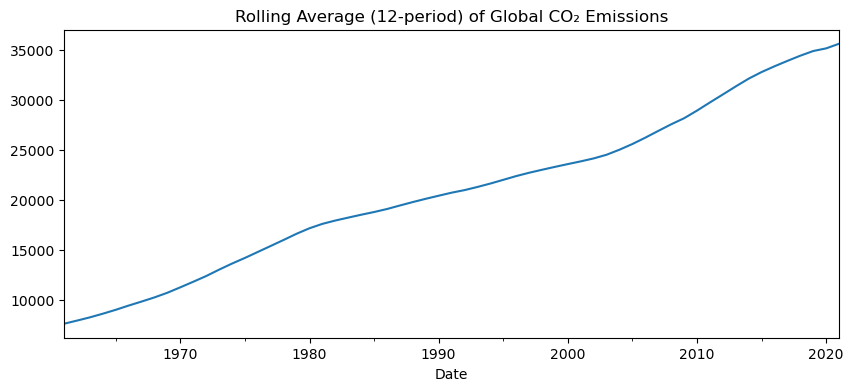

In [3]:
# Build stationary series for modeling
stationary_series = build_stationary_series(glob_df)
stationary_series.plot(title='Rolling Average (12-period) of Global CO₂ Emissions', figsize=(10,4))

In [4]:
# Run ADF test to check stationarity
adf_results = adf_test(stationary_series)
print("ADF Test Results (by lag):")
for lag, result in adf_results.items():
    print(f"Lag {lag}: ADF={result['adf_stat']:.4f}, p-value={result['p_value']:.4f}")

ADF Test Results (by lag):
Lag 1: ADF=-3.5695, p-value=0.0325
Lag 2: ADF=-3.5695, p-value=0.0325
Lag 3: ADF=-3.5695, p-value=0.0325
Lag 4: ADF=-3.5695, p-value=0.0325
Lag 5: ADF=-3.5695, p-value=0.0325
Lag 6: ADF=-3.5695, p-value=0.0325
Lag 7: ADF=-3.5695, p-value=0.0325
Lag 8: ADF=-3.5695, p-value=0.0325
Lag 9: ADF=-3.5695, p-value=0.0325
Lag 10: ADF=-3.5695, p-value=0.0325
Lag 11: ADF=-3.5695, p-value=0.0325
Lag 12: ADF=-3.5695, p-value=0.0325


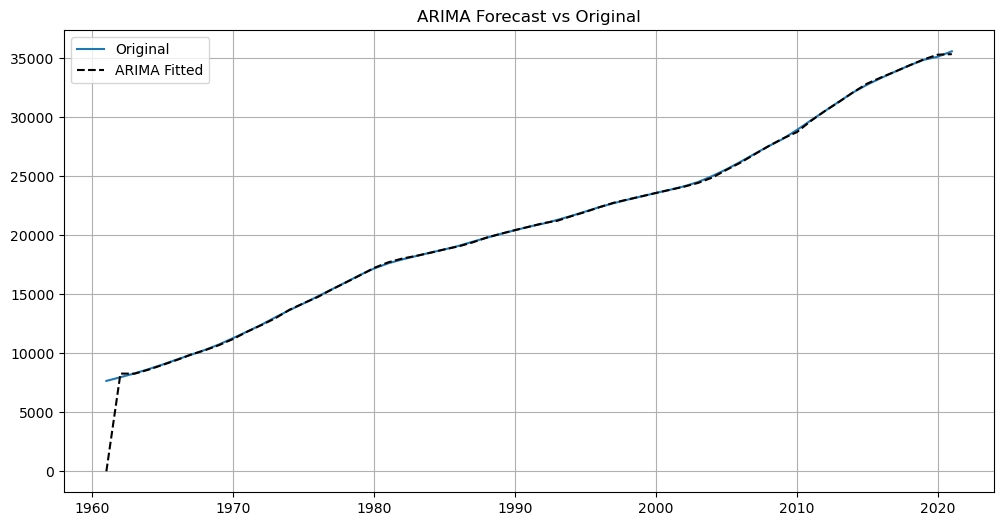

In [5]:
# Train ARIMA model and visualize fit
model = train_arima_model(stationary_series, order=(2,1,2))
plot_arima_fit(model, stationary_series)